In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# For reproducible results
np.random.seed(42)

n = 1000

# Student IDs
student_id = np.arange(1001, 1001 + n)

# Generate realistic student data
attendance = np.random.randint(50, 101, n)

study_hours = np.round(np.random.uniform(1, 8, n), 1)

previous_score = np.random.randint(40, 96, n)

assignment_score = np.random.randint(40, 101, n)

sleep_hours = np.round(np.random.uniform(4, 9, n), 1)

participation = np.random.randint(1, 11, n)

# Calculate final score using multiple factors
final_score = (
    0.20 * attendance +
    0.20 * (study_hours / 8 * 100) +
    0.25 * previous_score +
    0.20 * assignment_score +
    0.05 * (sleep_hours / 9 * 100) +
    0.10 * (participation / 10 * 100)
)

# Add some random variation
noise = np.random.normal(0, 5, n)

final_score = final_score + noise

# Keep score between 0 and 100
final_score = np.clip(final_score, 0, 100)

# Round final score
final_score = np.round(final_score, 2)

# Create DataFrame
df = pd.DataFrame({
    'Student_ID': student_id,
    'Attendance': attendance,
    'Study_Hours': study_hours,
    'Previous_Score': previous_score,
    'Assignment_Score': assignment_score,
    'Sleep_Hours': sleep_hours,
    'Participation': participation,
    'Final_Score': final_score
})

print("Dataset created successfully!")
print("Number of students:", len(df))

df.head(10)

Dataset created successfully!
Number of students: 1000


,Student_ID,Attendance,Study_Hours,Previous_Score,Assignment_Score,Sleep_Hours,Participation,Final_Score
0,1001,88,5.5,91,74,4.8,7,79.46
1,1002,78,4.4,73,80,7.2,4,72.04
2,1003,64,5.1,53,98,8.0,7,62.14
3,1004,92,6.2,75,53,8.7,7,68.11
4,1005,57,4.9,72,69,5.7,1,57.39
5,1006,70,5.1,62,80,7.6,6,63.96
6,1007,88,5.0,89,43,6.7,9,73.30
7,1008,68,3.7,84,98,4.3,2,70.27
8,1009,72,3.4,41,43,7.4,3,55.81
9,1010,60,7.3,80,67,7.5,10,81.87


In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(1000, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   int64  
 1   Attendance        1000 non-null   int64  
 2   Study_Hours       1000 non-null   float64
 3   Previous_Score    1000 non-null   int64  
 4   Assignment_Score  1000 non-null   int64  
 5   Sleep_Hours       1000 non-null   float64
 6   Participation     1000 non-null   int64  
 7   Final_Score       1000 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 62.6 KB

Missing Values:
Student_ID          0
Attendance          0
Study_Hours         0
Previous_Score      0
Assignment_Score    0
Sleep_Hours         0
Participation       0
Final_Score         0
dtype: int64

Statistical Summary:


,Student_ID,Attendance,Study_Hours,Previous_Score,Assignment_Score,Sleep_Hours,Participation,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1500.500000,75.232000,4.573900,67.346000,70.228000,6.588300,5.62800,66.550510
std,288.819436,14.651513,1.985727,15.999446,17.321318,1.416736,2.83225,9.279056
min,1001.000000,50.000000,1.000000,40.000000,40.000000,4.000000,1.00000,38.430000
25%,1250.750000,63.000000,2.900000,54.000000,56.000000,5.400000,3.00000,60.330000
50%,1500.500000,75.000000,4.700000,67.000000,71.000000,6.600000,6.00000,66.540000
75%,1750.250000,87.000000,6.225000,81.000000,85.000000,7.800000,8.00000,72.992500
max,2000.000000,100.000000,8.000000,95.000000,100.000000,9.000000,10.00000,97.400000


In [8]:
df.to_csv('student_performance_dataset.csv', index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [ ]:
data = pd.read_csv('student_performance_dataset.csv')

print("Dataset loaded successfully!")
display(data.head())

Dataset loaded successfully!


,Student_ID,Attendance,Study_Hours,Previous_Score,Assignment_Score,Sleep_Hours,Participation,Final_Score
0,1001,88,5.5,91,74,4.8,7,79.46
1,1002,78,4.4,73,80,7.2,4,72.04
2,1003,64,5.1,53,98,8.0,7,62.14
3,1004,92,6.2,75,53,8.7,7,68.11
4,1005,57,4.9,72,69,5.7,1,57.39


In [11]:
X = df[
    [
        'Attendance',
        'Study_Hours',
        'Previous_Score',
        'Assignment_Score',
        'Sleep_Hours',
        'Participation'
    ]
]

# Target variable
y = df['Final_Score']

print("Features:")
print(X.columns)

print("\nTarget:")
print("Final_Score")

Features:
Index(['Attendance', 'Study_Hours', 'Previous_Score', 'Assignment_Score',
       'Sleep_Hours', 'Participation'],
      dtype='object')

Target:
Final_Score


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [13]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 Predictions:")
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(
        "Actual:",
        round(actual, 2),
        "| Predicted:",
        round(predicted, 2)
    )

Predictions generated successfully!

First 10 Predictions:
Actual: 72.31 | Predicted: 68.58
Actual: 67.25 | Predicted: 62.83
Actual: 77.5 | Predicted: 69.9
Actual: 61.96 | Predicted: 60.82
Actual: 80.39 | Predicted: 80.93
Actual: 65.4 | Predicted: 68.21
Actual: 61.56 | Predicted: 65.11
Actual: 78.58 | Predicted: 78.09
Actual: 86.73 | Predicted: 76.37
Actual: 73.85 | Predicted: 68.46


In [15]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R² Score :", round(r2, 2))

Model Performance
-------------------------
MAE  : 4.02
MSE  : 25.01
RMSE : 5.0
R² Score : 0.72


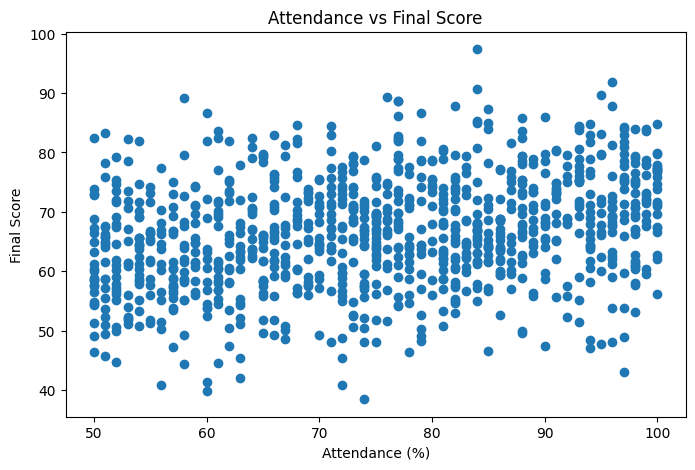

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Attendance'], df['Final_Score'])

plt.xlabel('Attendance (%)')
plt.ylabel('Final Score')
plt.title('Attendance vs Final Score')

plt.show()

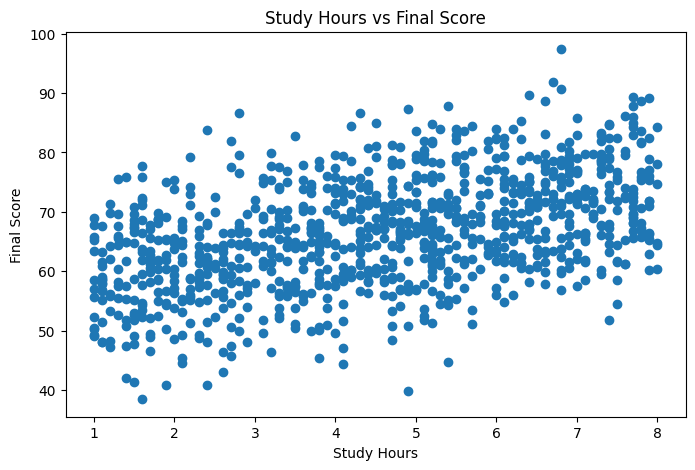

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Study_Hours'], df['Final_Score'])

plt.xlabel('Study Hours')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score')

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# New Section

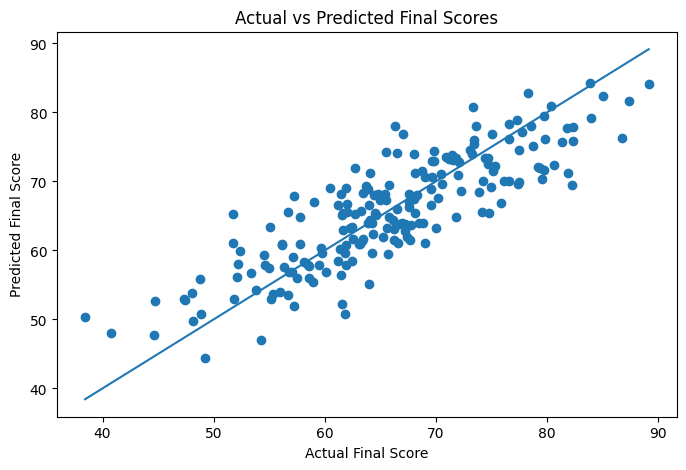

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Final Scores')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [21]:
new_student = pd.DataFrame({
    'Attendance': [85],
    'Study_Hours': [5],
    'Previous_Score': [78],
    'Assignment_Score': [82],
    'Sleep_Hours': [7],
    'Participation': [8]
})

predicted_score = model.predict(new_student)

print("Student Details:")
display(new_student)

print(
    "Predicted Final Score:",
    round(predicted_score[0], 2)
)

Student Details:


,Attendance,Study_Hours,Previous_Score,Assignment_Score,Sleep_Hours,Participation
0,85,5,78,82,7,8


Predicted Final Score: 77.02


In [22]:
score = predicted_score[0]

if score >= 75:
    performance = "Excellent"
elif score >= 60:
    performance = "Good"
elif score >= 40:
    performance = "Average"
else:
    performance = "Poor"

print("Predicted Final Score:", round(score, 2))
print("Performance Category:", performance)

Predicted Final Score: 77.02
Performance Category: Excellent
